In [2]:
using Pkg
Pkg.activate("/Users/jingqili/Documents/GitHub/i2lq_games_for_brain")
using iLQGames
import iLQGames: dx
using Plots
using ForwardDiff
using iLQGames:
    SystemTrajectory
using iLQGames:
    LinearSystem
using Infiltrator
using Optim
using LinearAlgebra
using Distributed
using Dates
using Statistics

  Activating environment at `~/Documents/GitHub/i2lq_games_for_brain/Project.toml`


In [23]:
include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

"Forward Game Problem: generate expert demo"
# parametes: number of states, number of inputs, sampling time, horizon
nx, nu, ΔT, game_horizon = 9, 4, 0.1, 40

# setup the dynamics
struct DoubleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::DoubleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2], 
                                    x[8]cos(x[7]), x[8]sin(x[7]), u[3], u[4],0)
dynamics = DoubleUnicycle()
costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-x[9])^2  +  2*(u[1]^2 + u[2]^2) )),
        FunctionPlayerCost((g, x, u, t) -> (  8*(x[5])^2 + 2*(u[3]^2 + u[4]^2) ))   )

# indices of inputs that each player controls
player_inputs = (SVector(1,2), SVector(3,4))
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)



# get a solver, choose initial conditions and solve (in about 9 ms with AD)
x0 = SVector(0.5, 0.5, pi/2, 1,       1, 0, pi/2, 1,         0.2)


# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)





(true, SystemTrajectory{40, 0.1, 9, 4, SizedVector{40, SVector{9, Float64}, Vector{SVector{9, Float64}}}, SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}}}(SVector{9, Float64}[[0.5, 0.5, 1.5707963267948966, 1.0, 1.0, 0.0, 1.5707963267948966, 1.0, 0.2], [0.49738688580862334, 0.6003362414316314, 1.6228057972271692, 1.007631528056232, 0.9915190013716659, 0.10283981139196424, 1.7336239222391523, 1.0660593031367305, 0.2], [0.4900301798945936, 0.7011798328648613, 1.664383386619281, 1.0147456829734374, 0.9667694288290325, 0.20958799990891375, 1.862423975633495, 1.1270505036901683, 0.2], [0.4788822200242167, 0.802352166243908, 1.6966662311168155, 1.0210360199527488, 0.9281966760207048, 0.3182578547362271, 1.9605778149401383, 1.1801272769401914, 0.2], [0.46480760827513184, 0.9037470338378584, 1.7207626206724478, 1.0263546046968761, 0.878573962882995, 0.42772104061353045, 2.031816416553032, 1.2240950391888288, 0.2], [0.4485784579426091, 1.0053084386171582, 1.7377317136515908, 1.

In [24]:
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]

40-element Vector{Float64}:
 0.0
 0.10283981139196424
 0.20958799990891375
 0.3182578547362271
 0.42772104061353045
 0.5375333831744598
 0.6477102965611007
 0.7585206345527066
 0.8703281696512792
 0.9834849958923038
 ⋮
 3.7684289461121527
 3.8990328439458577
 4.029634393898744
 4.160233308223286
 4.290829895318116
 4.421424712623296
 4.552018352520925
 4.682611323959863
 4.813203999003954

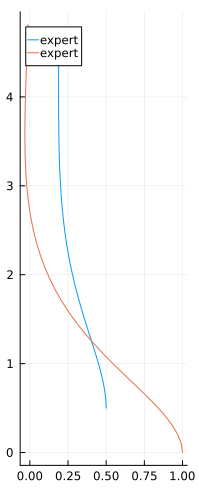

In [25]:
plot(agent1_x, agent1_y, label="expert", legend=:topleft)
plot!(agent2_x, agent2_y, label="expert", legend=:topleft)
plot!(size=(200,500))


In [35]:
function relu(x)
    return max.(0, x)
end

relu (generic function with 1 method)

In [37]:
relu([3;-4])

2-element Vector{Int64}:
 3
 0

In [53]:
include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

"Forward Game Problem: generate expert demo"
# parametes: number of states, number of inputs, sampling time, horizon
nx, nu, ΔT, game_horizon = 9, 4, 0.1, 40

# setup the dynamics
struct DoubleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::DoubleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2], 
                                    x[8]cos(x[7]), x[8]sin(x[7]), u[3], u[4],0)
dynamics = DoubleUnicycle()
costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-x[9])^2  +  2*(u[1]^2 + u[2]^2) + 20*relu( 1- (x[5]-x[1])^2 - (x[6]-x[2])^2 ) )),
        FunctionPlayerCost((g, x, u, t) -> (  8*(x[5] - x[9])^2 + 2*(u[3]^2 + u[4]^2) + 20*relu( 1- (x[5]-x[1])^2 - (x[6]-x[2])^2 ) ))   )

# indices of inputs that each player controls
player_inputs = (SVector(1,2), SVector(3,4))
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)



# get a solver, choose initial conditions and solve (in about 9 ms with AD)
x0 = SVector(
    0.5, 0., pi/2, 1,       
    1, 1, pi/2, 1,         
    0.2)
# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)


(true, SystemTrajectory{40, 0.1, 9, 4, SizedVector{40, SVector{9, Float64}, Vector{SVector{9, Float64}}}, SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}}}(SVector{9, Float64}[[0.5, 0.0, 1.5707963267948966, 1.0, 1.0, 1.0, 1.5707963267948966, 1.0, 0.2], [0.4973611620853391, 0.10034553422565881, 1.6233109195566215, 1.0078352193767115, 0.9930999484993023, 1.1020806916954922, 1.7047366810648246, 1.047802644196984, 0.2], [0.48993257603500917, 0.20121180427869256, 1.6652617943024746, 1.0151021127683233, 0.9731602135302304, 1.2071486078220837, 1.8112197341576746, 1.0920731548735638, 0.2], [0.4786776588863167, 0.30241148967491427, 1.6978165498204634, 1.021460207554096, 0.9422919252379915, 1.3138864303008757, 1.892932221431748, 1.130779506913564, 0.2], [0.4644720176024109, 0.40382894836642963, 1.7220863302017166, 1.0267405596296442, 0.9027333145556519, 1.4215206367270619, 1.9527879790429434, 1.1630323917456216, 0.2], [0.4480987629247378, 0.5053987791138074, 1.7391487886707697, 

┌ Info: Saved animation to 
│   fn = /Users/jingqili/Documents/GitHub/i2lq_games_for_brain/examples/expert_demo.gif
└ @ Plots /Users/jingqili/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/Users/jingqili/Documents/GitHub/i2lq_games_for_brain/examples/expert_demo.gif")
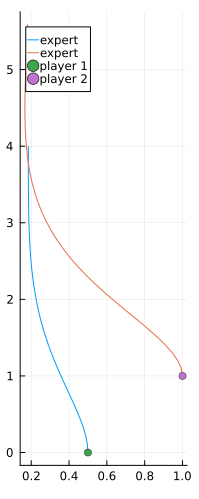

In [54]:
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]
anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, label="expert", legend=:topleft)
    plot!(agent2_x, agent2_y, label="expert", legend=:topleft)
    scatter!([agent1_x[t]], [agent1_y[t]], label="player 1", legend=:topleft)
    scatter!([agent2_x[t]], [agent2_y[t]], label="player 2", legend=:topleft)
    plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)
# scatter(agent1_x, agent1_y, label="player 1", legend=:topleft)
# scatter!(agent2_x, agent2_y, label="player 2", legend=:topleft)
# plot!(size=(200,500))



In [59]:
include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

"Forward Game Problem: generate expert demo"
# parametes: number of states, number of inputs, sampling time, horizon
nx, nu, ΔT, game_horizon = 9, 4, 0.1, 40

# setup the dynamics
struct DoubleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::DoubleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2], 
                                    x[8]cos(x[7]), x[8]sin(x[7]), u[3], u[4],0)
dynamics = DoubleUnicycle()
costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[3]-x[9])^2  +  2*(u[1]^2 + u[2]^2) + 0*relu( 1- (x[5]-x[1])^2 - (x[6]-x[2])^2 ) )),
        FunctionPlayerCost((g, x, u, t) -> (  8*(x[7] - x[9])^2 + 2*(u[3]^2 + u[4]^2) + 0*relu( 1- (x[5]-x[1])^2 - (x[6]-x[2])^2 ) ))   )

# indices of inputs that each player controls
player_inputs = (SVector(1,2), SVector(3,4))
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)



# get a solver, choose initial conditions and solve (in about 9 ms with AD)
x0 = SVector(
    0.5, 0., pi/2, 1,       
    1, 1, pi/2, 1,         
    pi)
# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)


(true, SystemTrajectory{40, 0.1, 9, 4, SizedVector{40, SVector{9, Float64}, Vector{SVector{9, Float64}}}, SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}}}(SVector{9, Float64}[[0.5, 0.0, 1.5707963267948966, 1.0, 1.0, 1.0, 1.5707963267948966, 1.0, 3.141592653589793], [0.48598882975374463, 0.09867904360180602, 1.852885322441562, 1.0, 0.9859888297537446, 1.0986790436018061, 1.852885322441562, 1.0, 3.141592653589793], [0.4473537762977372, 0.19067324603055053, 2.083916898694422, 1.0, 0.9473537762977372, 1.1906732460305507, 2.083916898694422, 1.0, 3.141592653589793], [0.3903385198239592, 0.27264556618436686, 2.2731323186035906, 1.0, 0.8903385198239592, 1.272645566184367, 2.2731323186035906, 1.0, 3.141592653589793], [0.32009371754057236, 0.34367845630297544, 2.4281001989654345, 1.0, 0.8200937175405724, 1.3436784563029756, 2.4281001989654345, 1.0, 3.141592653589793], [0.24054074983238777, 0.40415910561673996, 2.5550192549944275, 1.0, 0.7405407498323877, 1.4041591056167402, 2.5

┌ Info: Saved animation to 
│   fn = /Users/jingqili/Documents/GitHub/i2lq_games_for_brain/examples/expert_demo.gif
└ @ Plots /Users/jingqili/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/Users/jingqili/Documents/GitHub/i2lq_games_for_brain/examples/expert_demo.gif")
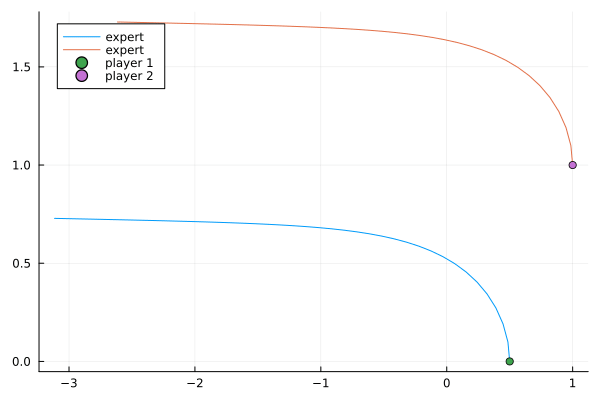

In [62]:
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]
agent1_θ = [expert_traj.x[t][3] for t in 1:game_horizon]
agent1_v = [expert_traj.x[t][4] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]
agent2_v = [expert_traj.x[t][8] for t in 1:game_horizon]
agent2_θ = [expert_traj.x[t][7] for t in 1:game_horizon]
anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, label="expert", legend=:topleft)
    plot!(agent2_x, agent2_y, label="expert", legend=:topleft)
    scatter!([agent1_x[t]], [agent1_y[t]], label="player 1", legend=:topleft)
    scatter!([agent2_x[t]], [agent2_y[t]], label="player 2", legend=:topleft)
    plot!(equal_aspect_ratio=true)
    # plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)
# scatter(agent1_x, agent1_y, label="player 1", legend=:topleft)
# scatter!(agent2_x, agent2_y, label="player 2", legend=:topleft)
# plot!(size=(200,500))



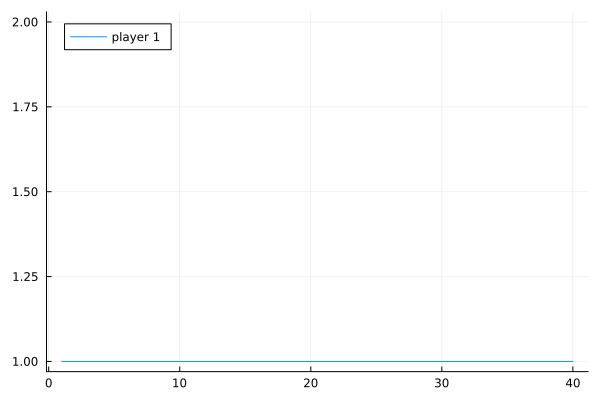

In [64]:
plot(agent1_v, label="player 1", legend=:topleft)

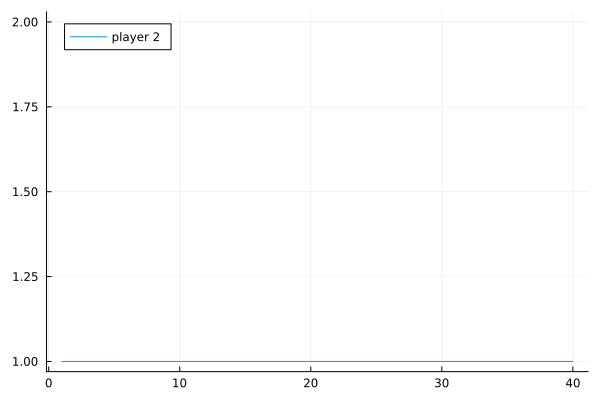

In [65]:
plot(agent2_v, label="player 2", legend=:topleft)

In [66]:
expert_traj.u

40-element SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}} with indices SOneTo(40):
 [2.8208899564666567, 0.0, 2.8208899564666567, 0.0]
 [2.3103157625285986, 0.0, 2.3103157625285986, 0.0]
 [1.8921541990916841, 0.0, 1.8921541990916841, 0.0]
 [1.5496788036184368, 0.0, 1.5496788036184368, 0.0]
 [1.2691905602899265, 0.0, 1.2691905602899265, 0.0]
 [1.0394699393730127, 0.0, 1.0394699393730127, 0.0]
 [0.8513281160310212, 0.0, 0.8513281160310212, 0.0]
 [0.6972394173302706, 0.0, 0.6972394173302706, 0.0]
 [0.5710402953227296, 0.0, 0.5710402953227296, 0.0]
 [0.46768278512809824, 0.0, 0.46768278512809824, 0.0]
 ⋮
 [0.0056274918689571095, 0.0, 0.0056274918689571095, 0.0]
 [0.004546015654581799, 0.0, 0.004546015654581799, 0.0]
 [0.0036463800663897386, 0.0, 0.0036463800663897386, 0.0]
 [0.002892599680854445, 0.0, 0.002892599680854445, 0.0]
 [0.0022545232825521705, 0.0, 0.0022545232825521705, 0.0]
 [0.001706627815552515, 0.0, 0.001706627815552515, 0.0]
 [0.0012269974611747118, 0.0, 0

In [84]:
# implement the receding horizon planning:
x0 = SVector(
    0.5, 0., pi/2, 1,       
    1, 1, pi/2, 1,         
    pi)
trajectory = [x0]
T = 3
for t in 1:T
    # 1. get the current state
    x = trajectory[end]
    # 2. solve the game with the current state
    c, expert_traj, strategies = solve(g, solver, x)
    # 3. get the optimal control
    u1 = expert_traj.u[1][1:2]
    u2 = expert_traj.u[1][3:4]
    # 4. apply the control to the system
    x = dx(dynamics, x, [u1; u2], t)
    print(x)
    push!(trajectory, x)
end


[6.123233995736766e-17, 1.0, 2.8208899564666567, 0.0, 6.123233995736766e-17, 1.0, 2.8208899564666567, 0.0, 0.0][-0.0, 0.0, -5.025962410977983, 0.0, -0.0, 0.0, -5.025962410977983, 0.0, 0.0][0.0, 0.0, 9.025795798514084, 0.0, 0.0, 0.0, 9.025795798514084, 0.0, 0.0]

┌ Info: Saved animation to 
│   fn = /Users/jingqili/Documents/GitHub/i2lq_games_for_brain/examples/expert_demo.gif
└ @ Plots /Users/jingqili/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/Users/jingqili/Documents/GitHub/i2lq_games_for_brain/examples/expert_demo.gif")
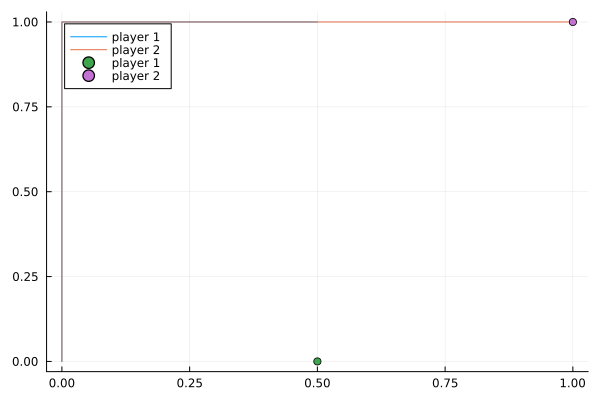

In [85]:

x1 = [trajectory[t][1] for t in 1:T]
y1 = [trajectory[t][2] for t in 1:T]
θ1 = [trajectory[t][3] for t in 1:T]
v1 = [trajectory[t][4] for t in 1:T]

x2 = [trajectory[t][5] for t in 1:T]
y2 = [trajectory[t][6] for t in 1:T]
v2 = [trajectory[t][8] for t in 1:T]
θ2 = [trajectory[t][7] for t in 1:T]

anim=@animate for t in 1:T
    plot(x1, y2, label="player 1", legend=:topleft)
    plot!(x2, y2, label="player 2", legend=:topleft)
    scatter!([x1[t]], [y1[t]], label="player 1", legend=:topleft)
    scatter!([x2[t]], [y2[t]], label="player 2", legend=:topleft)
    plot!(equal_aspect_ratio=true)
    # plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)

3-element Vector{Float64}:
 1.0
 0.0
 0.0

In [94]:
# new cost function for arc projection:
struct Arc
    center::Vector{Float64}
    radius::Float64
    start_angle::Float64
    end_angle::Float64
end

function sampled_projection(point::Vector{Float64}, arc::Arc, num_samples::Int)
    angles = LinRange(arc.start_angle, arc.end_angle, num_samples)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    # project the point onto the arc
    distances = [norm(point - p) for p in points]
    min_distance, min_index = findmin(distances)

    return points[min_index]
end

function project(point::Vector{Float64}, arc::Arc)
    # find the angle of the point with respect to the center of the arc
    angle = atan(point[2] - arc.center[2], point[1] - arc.center[1])

    # check if the angle is within the arc accounting for the 2pi rollover
    # first make sure start_angle < end_angle and angle > start_angle 
    start_angle = arc.start_angle % (2 * pi)
    end_angle = arc.end_angle % (2 * pi)
    if end_angle < start_angle
        end_angle += 2 * pi
    end

    if angle < start_angle
        angle += 2 * pi
    end

    # now, check if the angle is within the arc. if it is, then the projected point 
    # is in the interior of the arc. otherwise, it's one of the edge points. 
    if start_angle <= angle <= end_angle
        projected_point = arc.center .+ arc.radius * [cos(angle), sin(angle)]
    else
        start_vertex = arc.center .+ arc.radius * [cos(start_angle), sin(start_angle)]
        end_vertex = arc.center .+ arc.radius * [cos(end_angle), sin(end_angle)]
        distance_start_vertex = norm(point - start_vertex)
        distance_end_vertex = norm(point - end_vertex)
        if distance_start_vertex < distance_end_vertex
            projected_point = start_vertex
        else
            projected_point = end_vertex
        end
    end 

    return projected_point
end 

function project_and_distance(point, set)
    projected_point = project(point, set)
    distance = norm(point - projected_point)
    return projected_point, distance
end 

function plot_arc(arc::Arc)
    angles = LinRange(arc.start_angle, arc.end_angle, 100)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    plot!([p[1] for p in points], [p[2] for p in points])
end


plot_arc (generic function with 1 method)

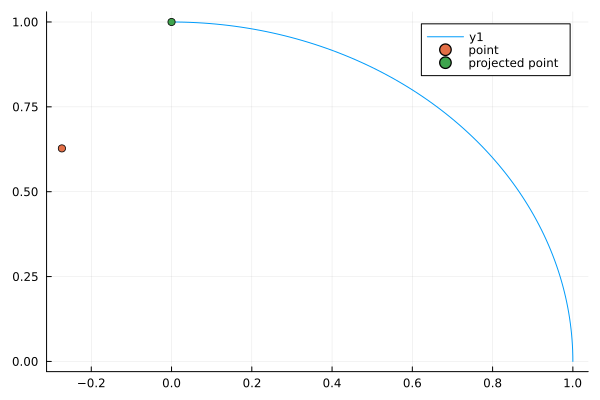

In [134]:
arc = Arc([0.0, 0.0], 1.0, 0, pi/2)
point = [2 * rand() - 1, 2 * rand() - 1]
projected_point = project(point, arc)
plot(equal_aspect_ratio=true)
plot_arc(arc)
scatter!([point[1]], [point[2]], label="point")
scatter!([projected_point[1]], [projected_point[2]], label="projected point")

